# Coding Task: Principal Component Analysis (PCA)

**Goal:** Understand PCA from scratch: mean-centering, covariance matrix, eigenvalue decomposition, and projections.

## What You Will Do

1. Generate a synthetic 2D dataset with two features that are correlated.
2. **Mean-center** the data.
3. Compute the **covariance matrix**.
4. Compute **eigenvalues and eigenvectors** (using NumPy).
5. Sort eigenvectors by eigenvalues (largest first = first principal component).
6. Project the data onto:
   - The first principal component (best 1D representation)
   - The last principal component (worst 1D representation)
   - The first two principal components (best 2D representation)
   - The last two principal components (if more than 2 dimensions; for 2D, the last two is same as both? We'll use a 3D dataset for worst two)
7. Visualise original data, mean-centered data, eigenvectors, and projections.
8. Answer questions about variance explained and reconstruction.

## Questions

1. What fraction of total variance is explained by the first principal component? By the second?
2. Why do we mean-center the data before PCA?
3. What happens if you project onto the *worst* principal component (lowest eigenvalue)? What information is lost?
4. Compare the scatter plots of original data vs. projection onto first PC. What shape do you see?
5. How would you choose the number of principal components to retain in practice?

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Set random seed
np.random.seed(42)

# Generate a 2D dataset with correlation (elongated shape)
X, _ = make_blobs(n_samples=200, centers=1, n_features=2, random_state=42)
# Add a linear transformation to create correlation
transform = np.array([[2, 1], [1, 1.5]])
X = X @ transform

print("Shape of data:", X.shape)

Shape of data: (200, 2)


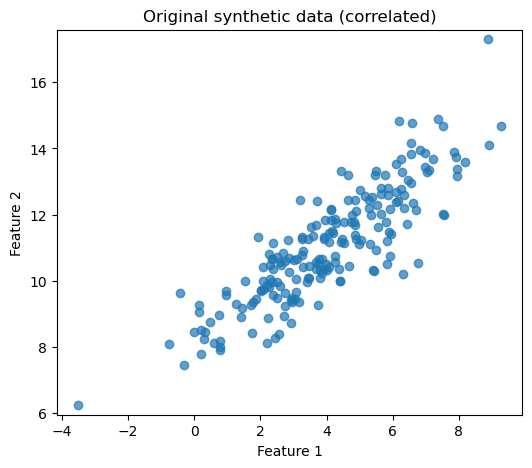

In [3]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Original synthetic data (correlated)')
plt.axis('equal')
plt.show()

In [7]:
# TODO: Compute the mean of each feature and subtract it from X
mean = np.mean(X, axis=0)
X_centered = X - mean

print("Mean of centered data (should be ~0):", np.mean(X_centered, axis=0))

Mean of centered data (should be ~0): [-1.15463195e-15  5.81756865e-16]


In [9]:
# TODO: Compute covariance matrix using the formula: (1/(n-1)) * X_centered.T @ X_centered
n = X_centered.shape[0]
cov_matrix = (1/(n-1)) * X_centered.T @ X_centered
print("Covariance matrix:\n", cov_matrix)

Covariance matrix:
 [[4.56659508 3.17520576]
 [3.17520576 2.96653555]]


In [11]:
# TODO: Use np.linalg.eig to get eigenvalues and eigenvectors
# eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues: [7.04100866 0.49212196]
Eigenvectors:
 [[ 0.78877292 -0.61468471]
 [ 0.61468471  0.78877292]]


In [13]:
# TODO: Sort eigenvalues in descending order and reorder eigenvectors accordingly
idx = np.argsort(eigenvalues)[::-1]          # indices from largest to smallest
sorted_eigenvalues = eigenvalues[idx]
sorted_eigenvectors = eigenvectors[:, idx]

print("Sorted eigenvalues:", sorted_eigenvalues)
print("Variance explained by PC1: {:.2f}%".format(100 * sorted_eigenvalues[0] / np.sum(sorted_eigenvalues)))
print("Variance explained by PC2: {:.2f}%".format(100 * sorted_eigenvalues[1] / np.sum(sorted_eigenvalues)))

Sorted eigenvalues: [7.04100866 0.49212196]
Variance explained by PC1: 93.47%
Variance explained by PC2: 6.53%


In [17]:
# Project onto first principal component (1D)
# TODO: X_pc1 = X_centered @ sorted_eigenvectors[:, 0].reshape(-1,1)
# Project onto first principal component (1D)
X_pc1 = X_centered @ sorted_eigenvectors[:, 0].reshape(-1,1)

# Project onto second principal component (1D) – the "worst" in 2D
X_pc2 = X_centered @ sorted_eigenvectors[:, 1].reshape(-1,1)

# Project onto first two principal components (2D)
X_pc12 = X_centered @ sorted_eigenvectors[:, :2]

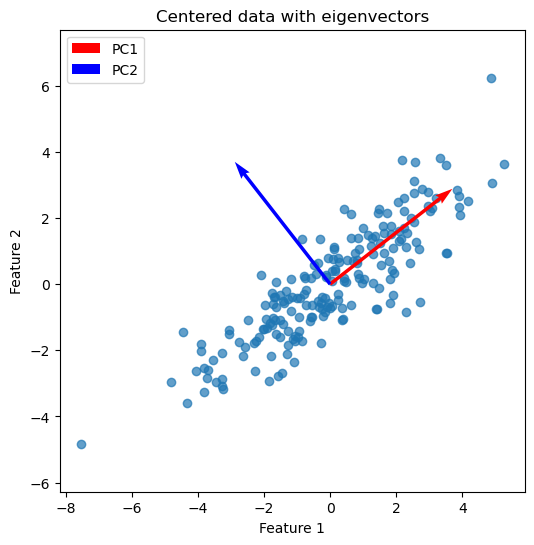

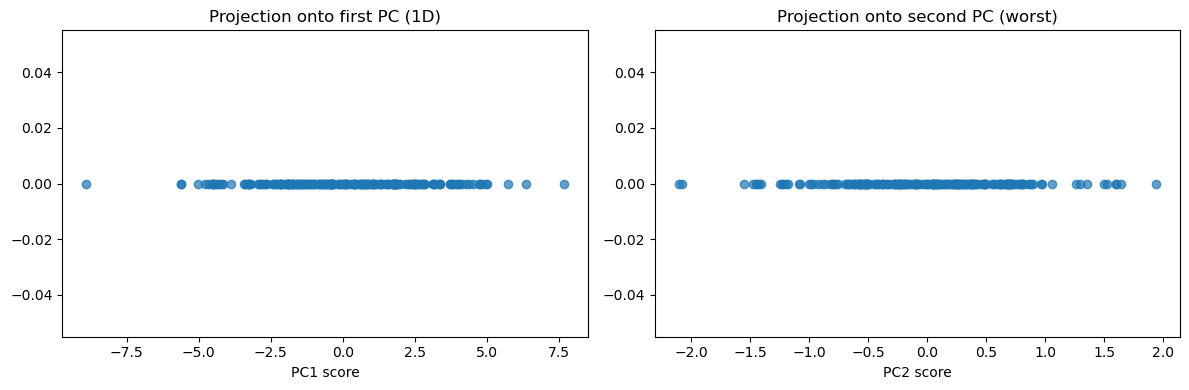

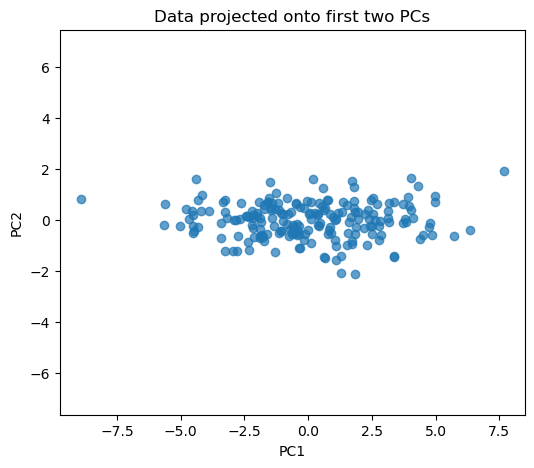

In [19]:
# Plot original centered data and eigenvectors
plt.figure(figsize=(6,6))
plt.scatter(X_centered[:,0], X_centered[:,1], alpha=0.7)
# Plot eigenvectors as arrows from origin
origin = np.zeros(2)
plt.quiver(*origin, sorted_eigenvectors[0,0], sorted_eigenvectors[1,0], color='r', scale=3, label='PC1')
plt.quiver(*origin, sorted_eigenvectors[0,1], sorted_eigenvectors[1,1], color='b', scale=3, label='PC2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Centered data with eigenvectors')
plt.legend()
plt.axis('equal')
plt.show()

# Plot projection onto PC1 (1D)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(X_pc1, np.zeros_like(X_pc1), alpha=0.7)
plt.title('Projection onto first PC (1D)')
plt.xlabel('PC1 score')
plt.subplot(1,2,2)
plt.scatter(X_pc2, np.zeros_like(X_pc2), alpha=0.7)
plt.title('Projection onto second PC (worst)')
plt.xlabel('PC2 score')
plt.tight_layout()
plt.show()

# Projection onto first two PCs (2D)
plt.figure(figsize=(6,5))
plt.scatter(X_pc12[:,0], X_pc12[:,1], alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Data projected onto first two PCs')
plt.axis('equal')
plt.show()

In [ ]:
## Questions to Answer

Write your answers below.

1. **What fraction of total variance is explained by the first principal component? By the second?**  
   (Look at the variance explained percentages printed in Cell 6.)

2. **Why do we mean-center the data before PCA?**  
   (Think about what would happen if we didn't center.)

3. **What happens if you project onto the worst principal component (lowest eigenvalue)? What information is lost?**  
   (Compare the spread of projections onto PC1 vs PC2.)

4. **Compare the scatter plots of original data vs. projection onto first PC. What shape do you see?**  
   (Is the projected data still 2D? How does it relate to the original distribution?)

5. **How would you choose the number of principal components to retain in practice?**  
   (Mention scree plot, cumulative variance threshold, or cross-validation.)